[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/user/repo/blob/main/notebook.ipynb)

# Lecture 10 Linear Regression
- Detection and Attribution

In [16]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf
from scipy import stats
import matplotlib.pyplot as plt

### Global Mean Temperature from GCMs

- Data

In [17]:
d = pd.read_csv("synthetic_DA_data.csv")
ctrl = pd.read_csv("synthetic_DA_control.csv")["control"]
d["fGHG"] = d["fALL"] - d["fAER"] - d["fNAT"]
 
o = d["obs_proxy"]
X = sm.add_constant(d[["fGHG", "fAER", "fNAT"]])

- OLS fit

In [18]:
# 2. OLS fit
res = sm.OLS(o, X).fit()
print(res.params.round(3))

const   -0.030
fGHG     0.877
fAER     0.726
fNAT     0.581
dtype: float64


In [19]:
# 3. Effective sample size
n, p = len(o), len(res.params)
r1 = acf(ctrl, nlags=1)[1]
n_eff = n * (1 - r1) / (1 + r1)
t = stats.t.ppf(0.975, n_eff - p)
print(r1)

0.40707755497772913


In [20]:
# 4. CI = β ± t × SE
beta = res.params.drop("const")
se = res.bse.drop("const") * np.sqrt(n / n_eff)
CI_high = beta + t * se
CI_low = beta - t * se

In [21]:
print('CI_high:\n',CI_high)
print('CI_low:\n',CI_low)

CI_high:
 fGHG    1.094786
fAER    1.340541
fNAT    1.289729
dtype: float64
CI_low:
 fGHG    0.660198
fAER    0.110933
fNAT   -0.128004
dtype: float64


## HW -- hands-on --

In [22]:
## 1. Data
d = pd.read_csv("NH_PI_DA_input.csv")
reg = d.dropna(subset=["year"]).copy()        # 1850-2005 (156 years)
control = d["NH_control"].dropna()            # 500-year control run
 
# Natural response: hist_aer = GHG + NAT  ->  NAT = hist_aer - GHG
reg["GHG"] = reg["NH_GHG"]
reg["AER"] = reg["NH_aerosols"]
reg["NAT"] = reg["NH_hist_aer"] - reg["NH_GHG"]
obs = reg["NH_obs_proxy"]
reg

,year,NH_obs_proxy,NH_GHG,NH_aerosols,NH_hist_aer,NH_control,SH_obs_proxy,SH_GHG,SH_aerosols,SH_hist_aer,SH_control,GHG,AER,NAT
0,1850.0,-0.3579,-1.1447,1.3348,-1.0064,0.2934,-0.0413,-0.8793,0.2623,-0.7343,-0.1909,-1.1447,1.3348,0.1383
1,1851.0,-0.1012,-1.0953,1.2948,-0.9675,0.3427,-0.3913,-0.9781,0.2043,-0.7888,-0.4851,-1.0953,1.2948,0.1278
2,1852.0,0.1311,-1.1265,1.4013,-1.0611,0.2626,-0.6678,-0.9249,0.1537,-0.8532,-0.3851,-1.1265,1.4013,0.0654
3,1853.0,-0.0063,-1.1401,1.2309,-1.1331,0.2031,-0.6465,-0.9712,0.2475,-0.9559,-0.3049,-1.1401,1.2309,0.0070
4,1854.0,0.1907,-1.1774,1.2162,-1.2177,0.7088,-0.7447,-1.0078,0.1722,-1.1383,-0.3687,-1.1774,1.2162,-0.0403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,2001.0,-0.0793,0.2444,-0.1167,0.3485,-0.1346,-0.0432,0.1754,-0.0181,0.3094,0.2632,0.2444,-0.1167,0.1041
152,2002.0,-0.1745,0.2282,-0.1588,0.4495,-0.2829,0.6179,0.2930,0.0459,0.5421,-0.0081,0.2282,-0.1588,0.2213
153,2003.0,0.0187,0.3191,-0.3008,0.4545,-0.2824,-0.3757,0.2774,0.0102,0.4242,-0.4854,0.3191,-0.3008,0.1354
154,2004.0,0.1140,0.3622,-0.3270,0.5001,0.0381,0.8173,0.2222,-0.0024,0.4324,0.2676,0.3622,-0.3270,0.1379


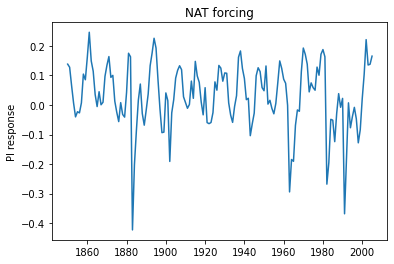

In [23]:
## plot Nat forcing 
plt.plot(reg["year"],reg["NAT"])
plt.title('NAT forcing')
plt.ylabel('PI response')
plt.savefig('PI_NA.png')

In [24]:
# 2. fit the OLS


In [25]:
# 3. Effective sample size from the control run


In [26]:
# 4. Corrected standard errors and t critical value


In [27]:
# 5. CI low and high


In [28]:
# 6. attributable cahnge (fit data with year)
## for 1850-2005
period = reg[(reg["year"] >= 1850) & (reg["year"] <= 2005)]


In [29]:
## for 1950-2005
period = reg[(reg["year"] >= 1950) & (reg["year"] <= 2005)]
